<a href="https://colab.research.google.com/github/UshenD/ID/blob/main/CombankLSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Commercial Bank Stock Price prediction Using LSTM**

**1.Loading dataset**


In [56]:
#importing the libraries
import numpy as np
import pandas as pd
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [57]:
com_df=pd.read_csv('/content/CSELK_COMB.N0000, D.csv')

In [58]:
com_df.shape

(2356, 6)

In [59]:
com_df.head()

,time,open,high,low,close,Volume
0,2016-01-18,102.988733,103.465908,102.591092,102.591092,150188.557233
1,2016-01-19,102.591092,102.591092,101.000533,101.795813,408628.044460
2,2016-01-20,103.386373,103.386373,99.409973,99.409973,152315.229179
3,2016-01-21,101.795813,101.795813,99.966669,101.000533,155092.463062
4,2016-01-22,102.591092,105.772212,102.591092,103.386373,149224.523206


**2.Data Pre-processing**

In [60]:
#checking for null values
com_df.isna().sum()

,0
time,0
open,0
high,0
low,0
close,0
Volume,0


In [61]:
com_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2356 entries, 0 to 2355
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    2356 non-null   object 
 1   open    2356 non-null   float64
 2   high    2356 non-null   float64
 3   low     2356 non-null   float64
 4   close   2356 non-null   float64
 5   Volume  2356 non-null   float64
dtypes: float64(5), object(1)
memory usage: 110.6+ KB


In [62]:
#converting the dataype of 'time' column to 'datetime'
com_df['time'] = pd.to_datetime(com_df['time'])

In [63]:
#making the 'time' col as index
com_df.set_index('time', inplace = True)

In [64]:
com_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2356 entries, 2016-01-18 to 2026-04-06
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    2356 non-null   float64
 1   high    2356 non-null   float64
 2   low     2356 non-null   float64
 3   close   2356 non-null   float64
 4   Volume  2356 non-null   float64
dtypes: float64(5)
memory usage: 110.4 KB


In [65]:
#sort the indexes
com_df.sort_index(inplace = True)

In [66]:
#data normalization
target_column = 'close'
feature_columns = ['open', 'high', 'low', 'Volume']  # Excluding 'close' from features to prevent leakage!

#Create separate scalers
feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

# Scale features (open, high, low, volume)
features_scaled = feature_scaler.fit_transform(com_df[feature_columns])

In [67]:
# Scale target (close) separately
target_scaled = target_scaler.fit_transform(com_df[[target_column]])


In [68]:
print(f"\nFeatures shape: {features_scaled.shape}")
print(f"Target shape: {target_scaled.shape}")


Features shape: (2356, 4)
Target shape: (2356, 1)


**3.Sliding window sequence creation**

In [69]:
window_size = 10

def create_sequences(features, target, window_size):
    X, y = [], []
    for i in range(window_size, len(features)):
        X.append(features[i-window_size:i])
        y.append(target[i])
    return np.array(X), np.array(y)

X, y = create_sequences(features_scaled, target_scaled, window_size)


In [70]:
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (2346, 10, 4)
y shape: (2346, 1)


**4.Train-Test,Split**

In [71]:
#train-test-split

split_ratio = 0.8
split_idx = int(len(X) * split_ratio)

X_train = X[:split_idx]
X_test = X[split_idx:]
y_train = y[:split_idx]
y_test = y[split_idx:]

In [72]:
print(f"\nTraining samples: {X_train.shape[0]} ({split_ratio*100:.0f}%)")
print(f"Test samples: {X_test.shape[0]} ({(1-split_ratio)*100:.0f}%)")


Training samples: 1876 (80%)
Test samples: 470 (20%)


**6.Build LSTM model**

In [73]:
import tensorflow.keras as keras
model = keras.Sequential([
    keras.layers.LSTM(units=32, return_sequences=True,
                      input_shape=(X_train.shape[1], X_train.shape[2])),
    keras.layers.Dropout(0.2),

    keras.layers.LSTM(units=16, return_sequences=False),
    keras.layers.Dropout(0.2),

    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1)
])

optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
              loss='mean_squared_error',
              metrics=['mae'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 10, 32)         │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,017 (31.32 KB)

 Trainable params: 8,017 (31.32 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
#callbacks
from tensorflow.keras.callbacks import ReduceLROnPlateau # Ensuring ReduceLROnPlateau is imported
early_stopping = EarlyStopping(monitor='val_loss', patience=15,
                               restore_best_weights=True, verbose=1)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=5, min_lr=0.00001, verbose=1)

In [75]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0071 - mae: 0.0571 - val_loss: 7.0499e-04 - val_mae: 0.0207 - learning_rate: 0.0010
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0016 - mae: 0.0294 - val_loss: 5.0291e-04 - val_mae: 0.0171 - learning_rate: 0.0010
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0013 - mae: 0.0263 - val_loss: 3.7952e-04 - val_mae: 0.0151 - learning_rate: 0.0010
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.0389e-04 - mae: 0.0219 - val_loss: 5.1325e-04 - val_mae: 0.0169 - learning_rate: 0.0010
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.3750e-04 - mae: 0.0201 - val_loss: 3.6308e-04 - val_mae: 0.0142 - learning_rate: 0.0010
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.9696e-04 - mae: 0.0191 - val_loss: 3.6439e-04 - val_mae: 0.0150 - learning_rate: 0.0010
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.6564e-04 - mae: 0.0175 - val_loss: 4.4229e-04 - va

In [76]:
#making predictions
print("\nMaking predictions...")
predictions_scaled = model.predict(X_test)
predictions = target_scaler.inverse_transform(predictions_scaled)
y_test_actual = target_scaler.inverse_transform(y_test)


Making predictions...
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


In [77]:
#Calculating the metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test_actual, predictions)
mse = mean_squared_error(y_test_actual, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, predictions)

directional_accuracy = np.mean(
    ((predictions[1:] - predictions[:-1]) * (y_test_actual[1:] - y_test_actual[:-1])) > 0
) * 100

print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print(f"Directional Accuracy: {directional_accuracy:.1f}%")

MODEL PERFORMANCE METRICS
MAE:  12.0625
MSE:  219.3118
RMSE: 14.8092
R²:   0.8853
Directional Accuracy: 48.6%


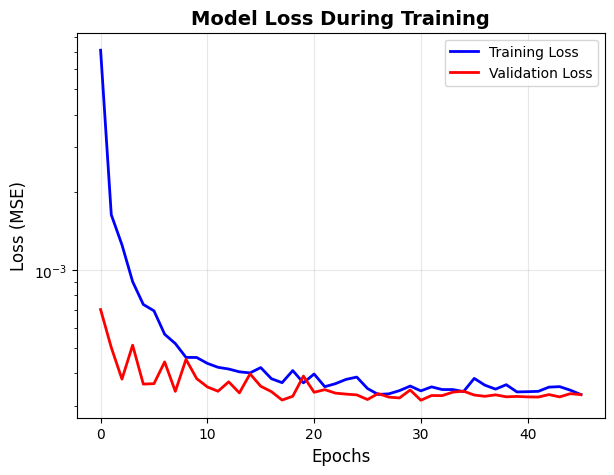

In [78]:
# PLOT 1: Training & Validation Loss Over Epochs
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
plt.title('Model Loss During Training', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.yscale('log')

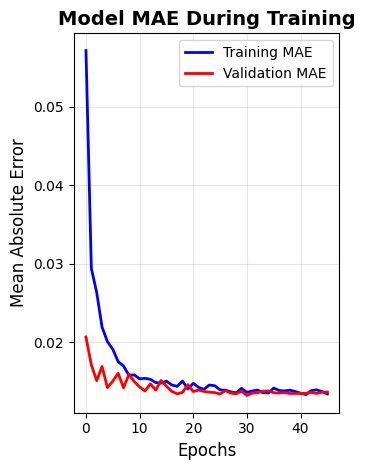

In [79]:
# PLOT 2: Training MAE Over Epochs
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE', linewidth=2, color='blue')
plt.plot(history.history['val_mae'], label='Validation MAE', linewidth=2, color='red')
plt.title('Model MAE During Training', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Absolute Error', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

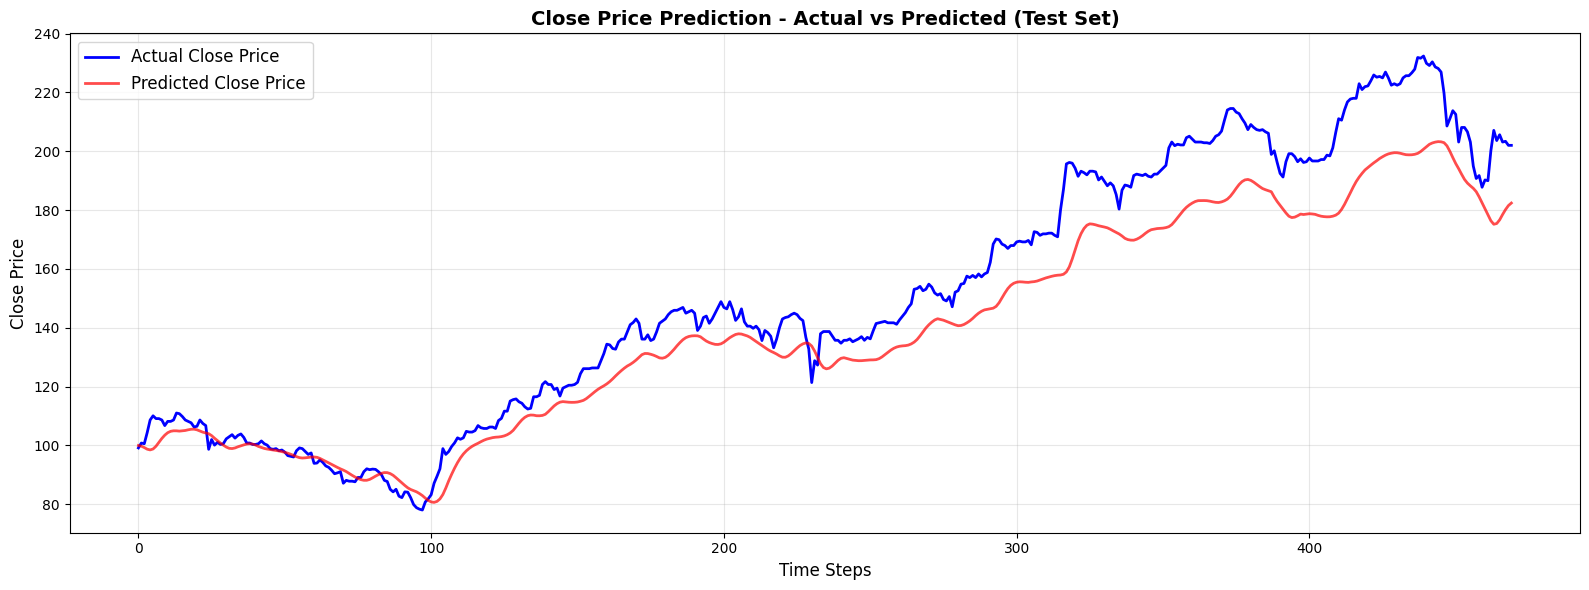

In [80]:
#Actual vs Predicted Close Prices (Test Set)
plt.figure(figsize=(16, 6))
plt.plot(y_test_actual, color='blue', label='Actual Close Price', linewidth=2)
plt.plot(predictions, color='red', label='Predicted Close Price', linewidth=2, alpha=0.7)
plt.title('Close Price Prediction - Actual vs Predicted (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Close Price', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

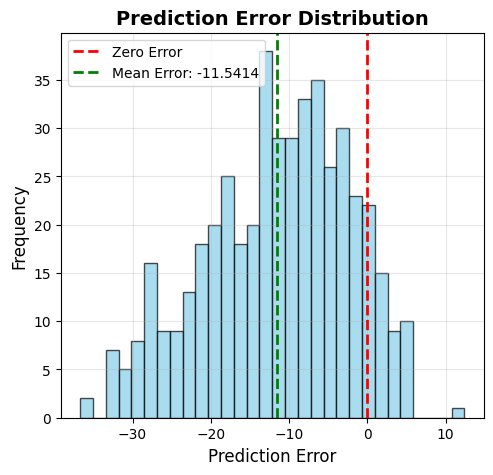

In [81]:
#Prediction Error Distribution
plt.figure(figsize=(12, 5))
errors = predictions.flatten() - y_test_actual.flatten()
plt.subplot(1, 2, 1)
plt.hist(errors, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.axvline(x=np.mean(errors), color='green', linestyle='--', linewidth=2,
            label=f'Mean Error: {np.mean(errors):.4f}')
plt.title('Prediction Error Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Prediction Error', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

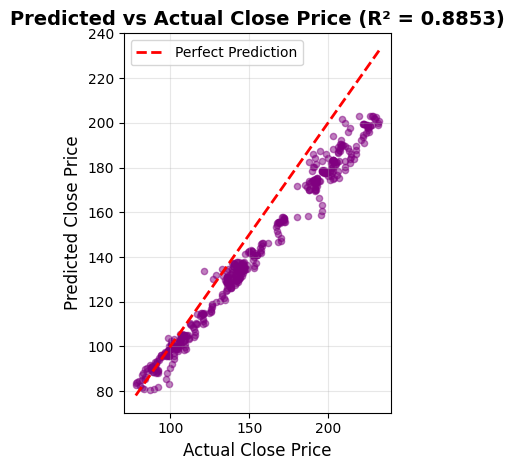

In [82]:
#Scatter Plot - Predicted vs Actual
plt.subplot(1, 2, 2)
plt.scatter(y_test_actual, predictions, alpha=0.5, s=20, color='purple')
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual Close Price (R² = {r2:.4f})', fontsize=14, fontweight='bold')
plt.xlabel('Actual Close Price', fontsize=12)
plt.ylabel('Predicted Close Price', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


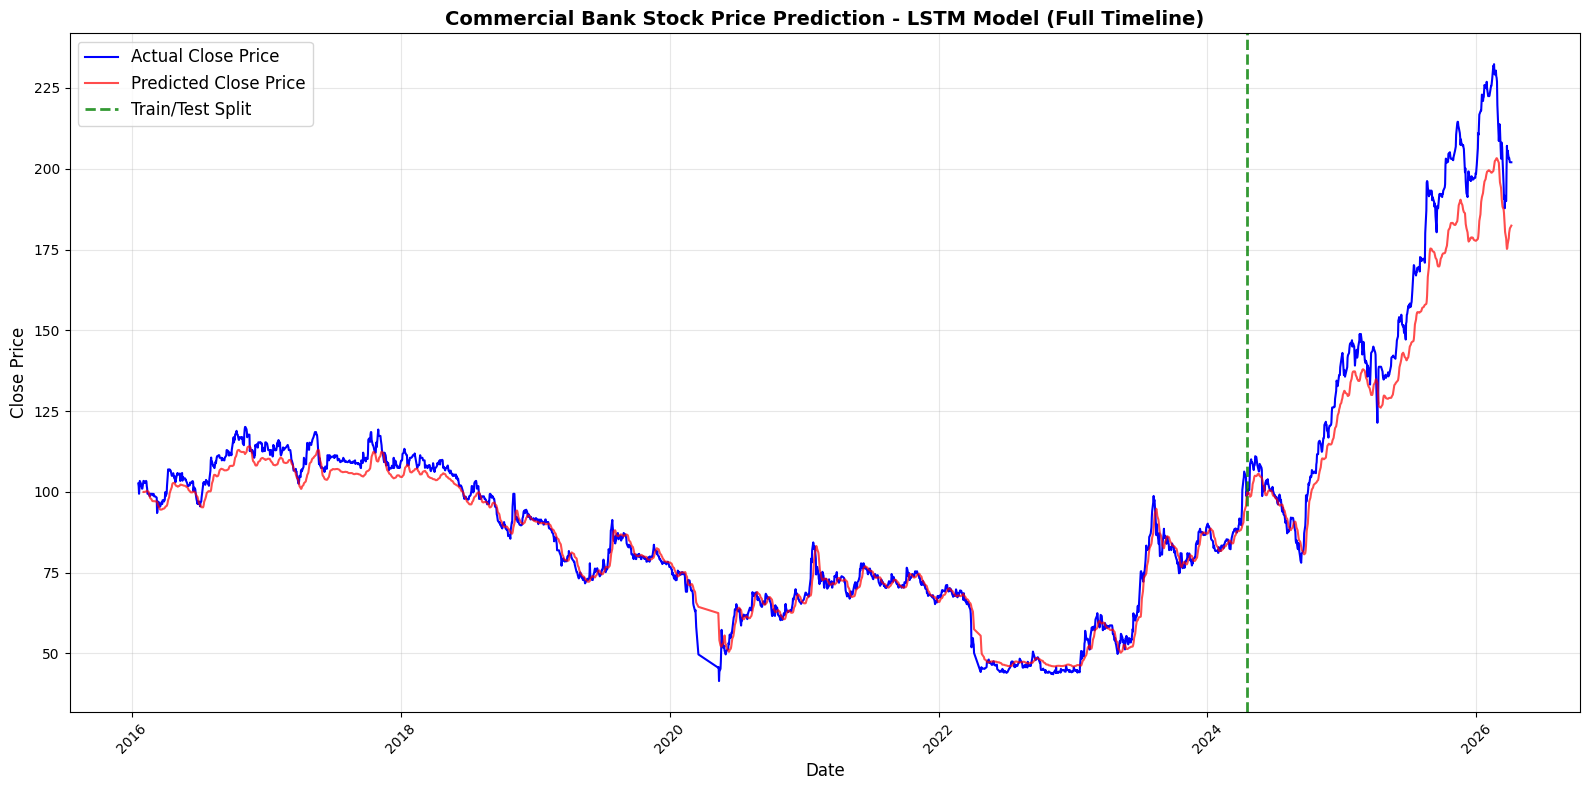

In [83]:
#Full Timeline with Train/Test Split
# Predict on entire dataset
all_predictions_scaled = model.predict(X)
all_predictions = target_scaler.inverse_transform(all_predictions_scaled)

# Create arrays with proper alignment
full_actual = target_scaler.inverse_transform(target_scaled)
full_predictions = np.full((len(full_actual), 1), np.nan)
full_predictions[window_size:] = all_predictions

plt.figure(figsize=(16, 8))
plt.plot(com_df.index, full_actual, label='Actual Close Price', color='blue', linewidth=1.5)
plt.plot(com_df.index, full_predictions, label='Predicted Close Price',
         color='red', linewidth=1.5, alpha=0.7)

# Mark train/test split
split_date = com_df.index[split_idx + window_size]
plt.axvline(x=split_date, color='green', linestyle='--',
            linewidth=2, label='Train/Test Split', alpha=0.8)

plt.title('Commercial Bank Stock Price Prediction - LSTM Model (Full Timeline)',
          fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

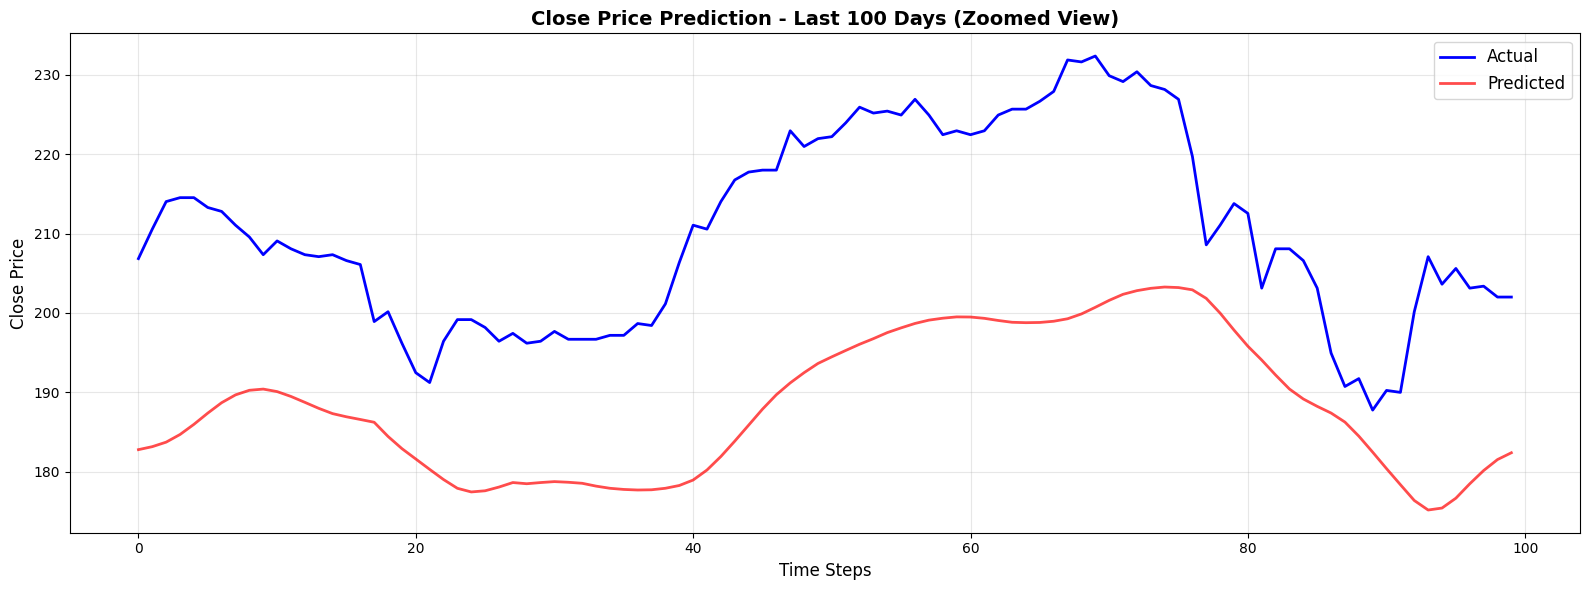

In [84]:
#Zoomed View (Last 100 days)
zoom_days = min(100, len(y_test_actual))
plt.figure(figsize=(16, 6))
plt.plot(y_test_actual[-zoom_days:], color='blue', label='Actual', linewidth=2)
plt.plot(predictions[-zoom_days:], color='red', label='Predicted', linewidth=2, alpha=0.7)
plt.title(f'Close Price Prediction - Last {zoom_days} Days (Zoomed View)',
          fontsize=14, fontweight='bold')
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Close Price', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

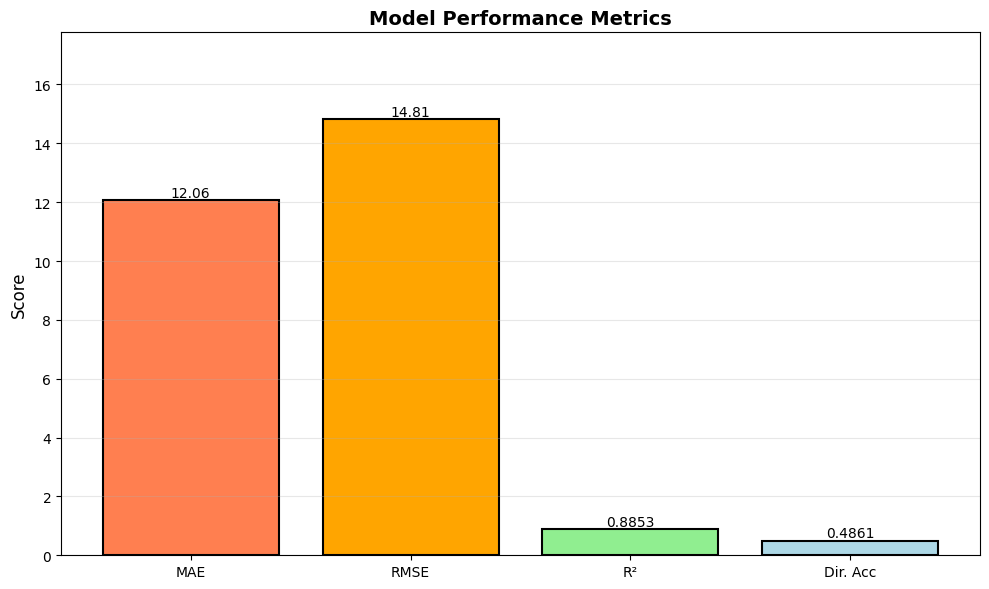

In [85]:
#Feature Importance / Model Architecture Summary
plt.figure(figsize=(10, 6))
metrics_names = ['MAE', 'RMSE', 'R²', 'Dir. Acc']
metrics_values = [mae, rmse, r2, directional_accuracy/100]
colors_metrics = ['coral', 'orange', 'lightgreen', 'lightblue']

bars = plt.bar(metrics_names, metrics_values, color=colors_metrics, edgecolor='black', linewidth=1.5)
plt.title('Model Performance Metrics', fontsize=14, fontweight='bold')
plt.ylabel('Score', fontsize=12)
plt.ylim(0, max(metrics_values) * 1.2)

# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{value:.4f}' if value < 1 else f'{value:.2f}',
             ha='center', va='bottom', fontsize=10)

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

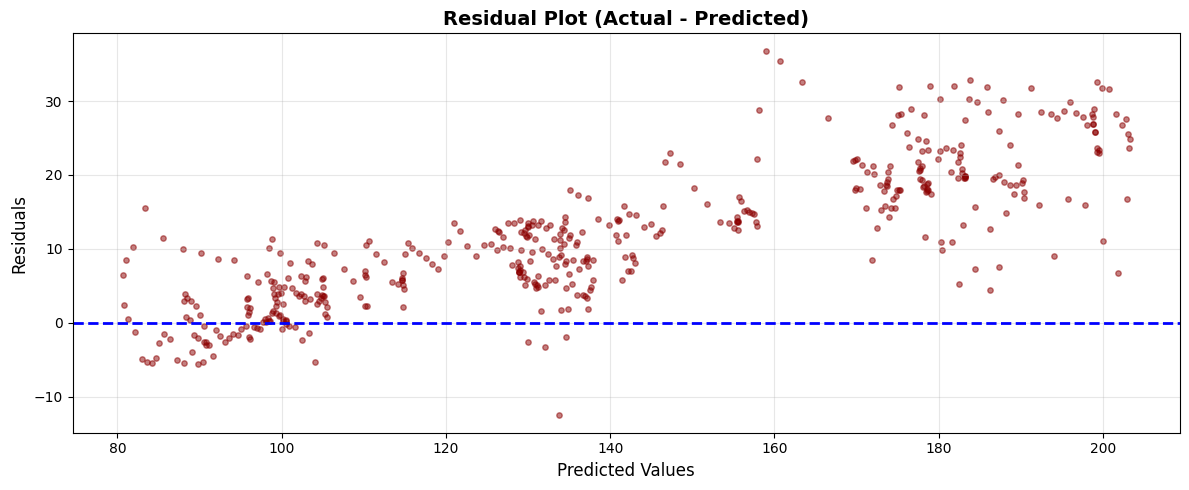

In [86]:
#Residual Plot
plt.figure(figsize=(12, 5))
residuals = y_test_actual.flatten() - predictions.flatten()
plt.scatter(predictions.flatten(), residuals, alpha=0.5, s=15, color='darkred')
plt.axhline(y=0, color='blue', linestyle='--', linewidth=2)
plt.title('Residual Plot (Actual - Predicted)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

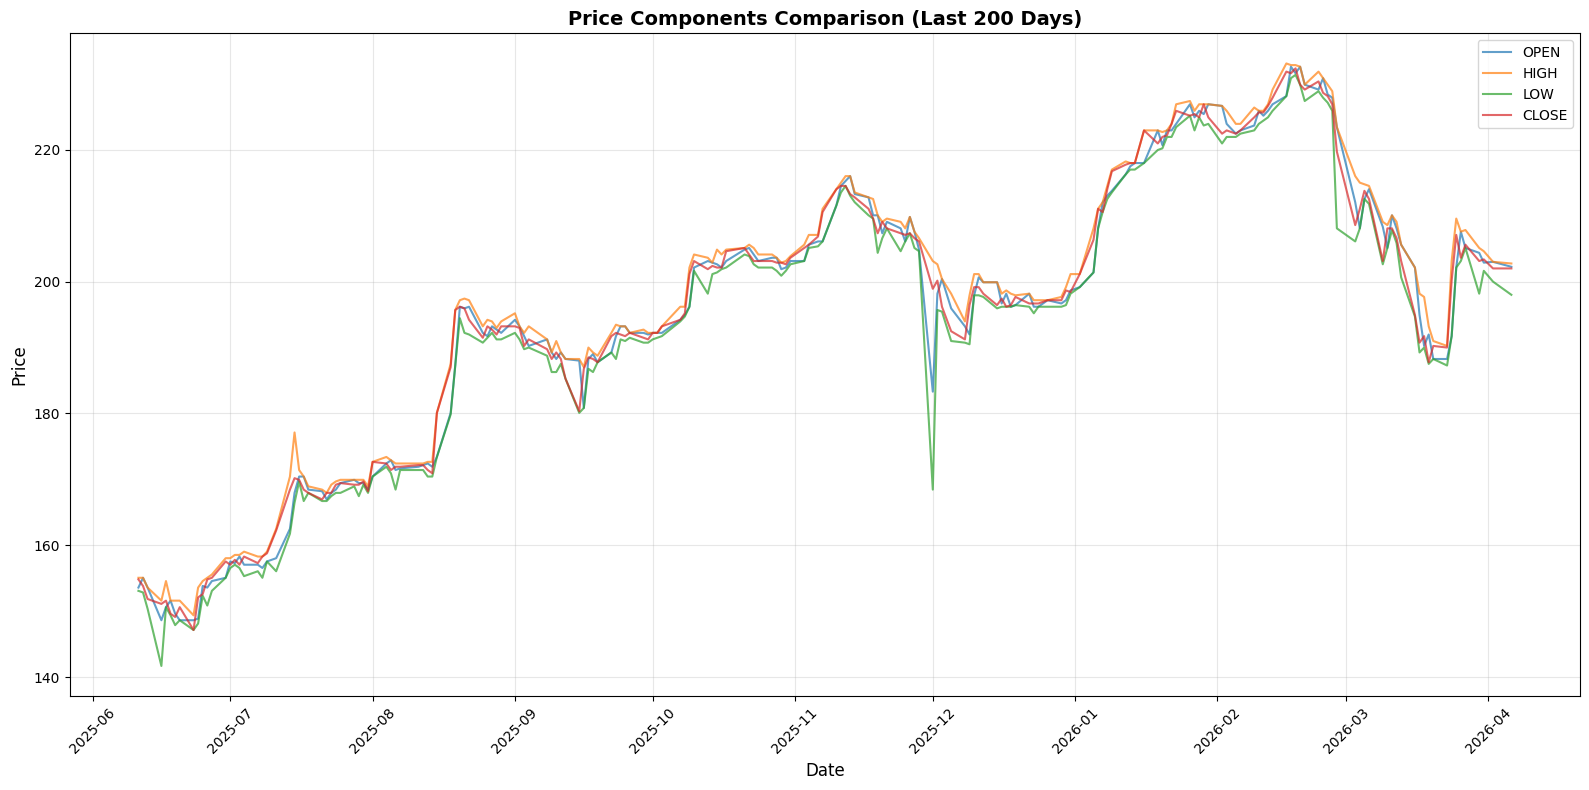

In [87]:
# Comparison of All Price Columns (Open, High, Low, Close)
plt.figure(figsize=(16, 8))
for col in ['open', 'high', 'low', 'close']:
    if col in com_df.columns:
        plt.plot(com_df.index[-200:], com_df[col][-200:], label=col.upper(), linewidth=1.5, alpha=0.7)

plt.title('Price Components Comparison (Last 200 Days)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

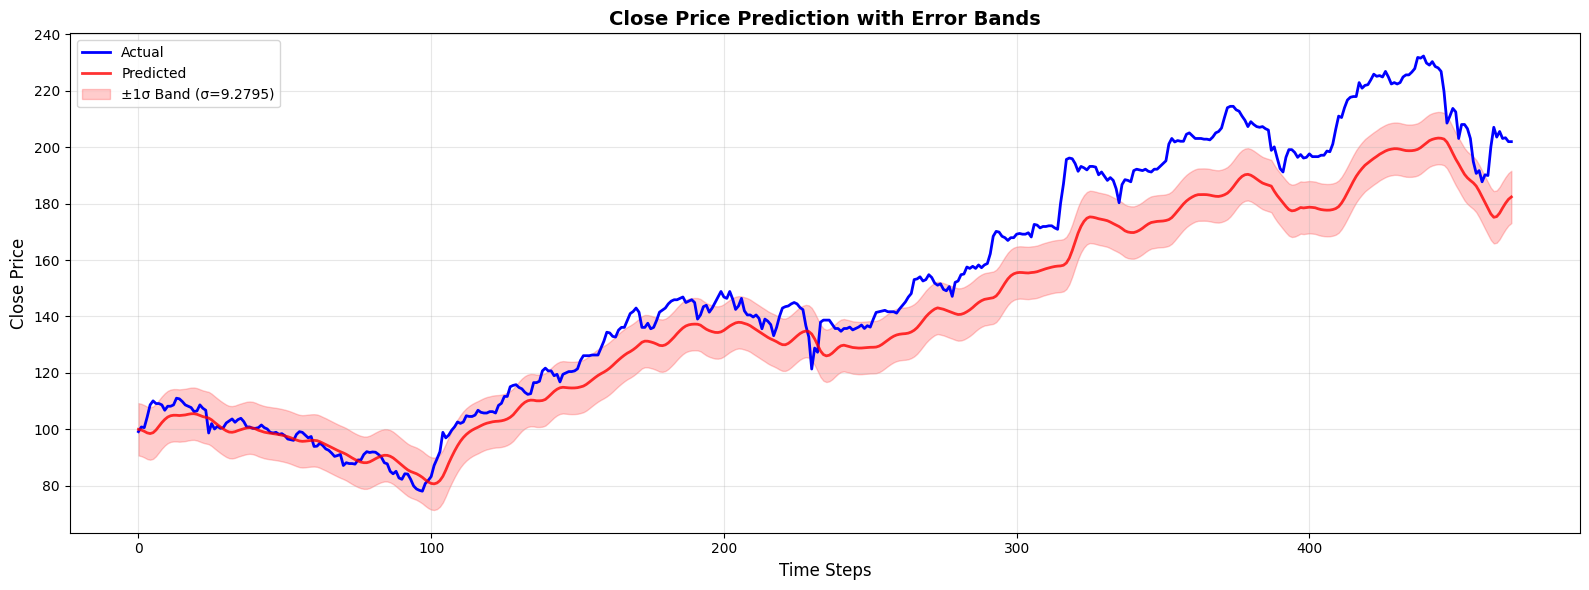

In [88]:
#Actual vs Predicted with Confidence Bands (Simplified)
plt.figure(figsize=(16, 6))
plt.plot(y_test_actual, color='blue', label='Actual', linewidth=2)
plt.plot(predictions, color='red', label='Predicted', linewidth=2, alpha=0.8)

# Add simple confidence band (±1 standard deviation of error)
error_std = np.std(errors)
plt.fill_between(range(len(predictions)),
                 predictions.flatten() - error_std,
                 predictions.flatten() + error_std,
                 alpha=0.2, color='red', label=f'±1σ Band (σ={error_std:.4f})')

plt.title('Close Price Prediction with Error Bands', fontsize=14, fontweight='bold')
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Close Price', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

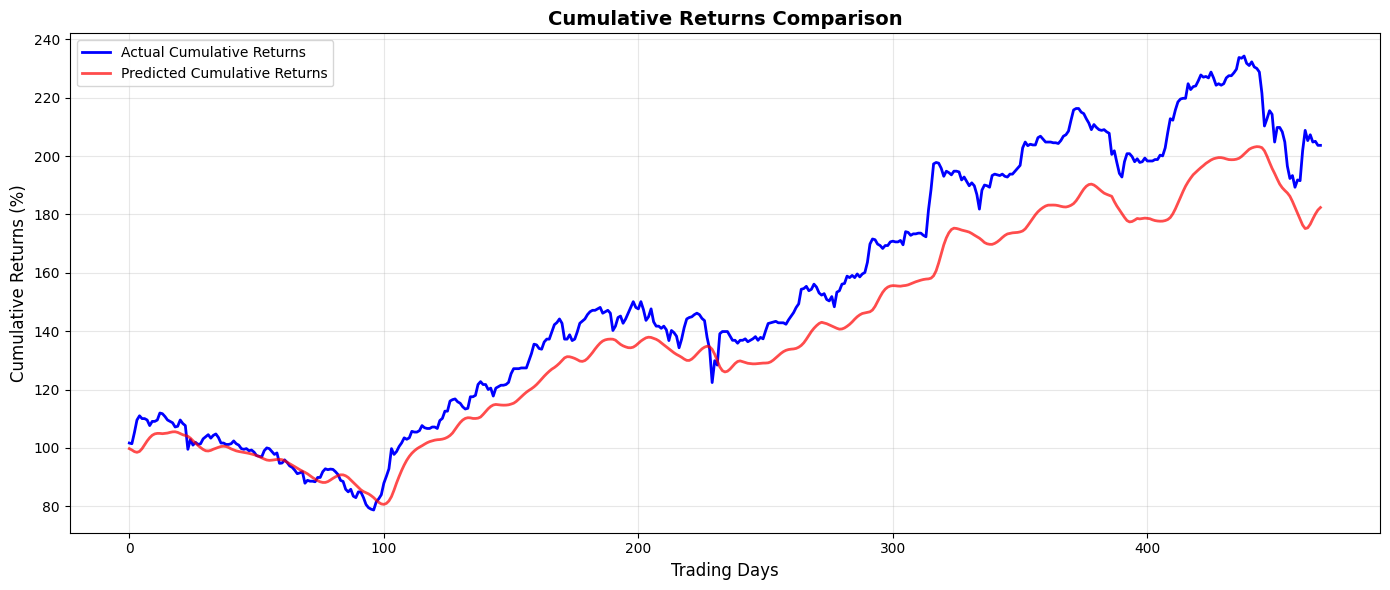

In [89]:
#Cumulative Returns Comparison
# Calculate daily returns
actual_returns = np.diff(y_test_actual.flatten()) / y_test_actual[:-1].flatten()
predicted_returns = np.diff(predictions.flatten()) / predictions[:-1].flatten()

# Calculate cumulative returns
cumulative_actual = np.cumprod(1 + actual_returns) * 100
cumulative_predicted = np.cumprod(1 + predicted_returns) * 100

plt.figure(figsize=(14, 6))
plt.plot(cumulative_actual, label='Actual Cumulative Returns', color='blue', linewidth=2)
plt.plot(cumulative_predicted, label='Predicted Cumulative Returns', color='red', linewidth=2, alpha=0.7)
plt.title('Cumulative Returns Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Trading Days', fontsize=12)
plt.ylabel('Cumulative Returns (%)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()